# Cartesian Step-Update Filter

In [1]:
"""
    TITLE   : Kalman Filter for Track with Step-by-Step Updates
    PROJECT : trackstream
""";

__author__ = 'Nathaniel Starkman'

<span style='font-size:30px;font-weight:650'>
    About
</span>



<br><br>

- - - 


## Prepare

### Imports

In [2]:
from utilipy import ipython

ipython.set_autoreload(2)
ipython.run_imports(base=True, astropy=True, matplotlib=True)

# BUILT-IN

from collections import namedtuple

# THIRD PARTY

from filterpy.kalman import KalmanFilter
from filterpy.kalman import predict, update, rts_smoother
from filterpy.common import Saver
from filterpy.common import Q_discrete_white_noise, Q_continuous_white_noise
from filterpy.stats import plot_covariance

from numpy import dot

from scipy.linalg import block_diag, inv


# PROJECT-SPECIFIC

import trackstream as st
from trackstream import examples
from trackstream import preprocess as prep, process
from trackstream.utils import convert


set autoreload to 1
set autoreload to 2


### Functions

In [3]:
def make_dts(ordered_data, dt0, *, N=6, vmin=0.01, axis=1, plot=False):
    ii = np.arange(len(ordered_data)-1)  # indices
    ds = np.linalg.norm(ordered_data[1:] - ordered_data[:-1], axis=axis)  # point-to-point distance

    Ds = np.convolve(ds, np.ones((N,))/N, mode='same')
    Ds[Ds < vmin] = vmin

    dts = np.insert(Ds, 0, values=dt0)
    
    if plot:
        fig, ax = plt.subplots()
        ax.scatter(ii, ds, label="p2p distance")
        ax.scatter(ii, Ds, label="convolved")
        ax.set_xlabel("index")
        ax.set_ylabel("distance")
        ax.set_title("point to point distance")

        plt.legend()
        plt.tight_layout()
        plt.show
    
    return dts


In [4]:
def make_F(dt):
    F_comp = np.array([[1, dt],
                       [0, 1]])
    F = block_diag(F_comp, F_comp, F_comp)
    return F
# /def

In [5]:
def make_Q(dt, dim=2, var=1, block_size=3):
    Q = Q_discrete_white_noise(dim=dim, dt=dt, var=var, block_size=block_size)
    return Q
# /def

In [6]:
run_output = namedtuple("run_output", field_names=["Xs", "Ps", "Fs", "Qs"])

def run_with_updatestep(data, dts, x0, P, R, H, u=0., B=0, alpha=1., *, qkw={}):
    x = x0

    Xs, Ps, Fs, Qs = [], [], [], []
    for i, z in enumerate(data):
        # F, Q
        F = make_F(dts[i])
        Q = make_Q(dts[i], **qkw)

        # predict
        x, P = predict(x, P=P, F=F, Q=Q, u=u, B=B, alpha=alpha)

        # update
        x, P, y, K, S, loglik = update(x, P=P, z=z, R=R, H=H, return_all=True)

        Xs.append(x)
        Ps.append(P)
        Fs.append(F)
        Qs.append(Q)

    Xs, Ps = np.array(Xs), np.array(Ps)
    Fs, Qs = np.array(Fs), np.array(Qs)

    # smooth
    sXs, sPs, sFs, sQs = rts_smoother(Xs, Ps, Fs, Qs)
    
    output = run_output(Xs, Ps, Fs, Qs)
    smooth = run_output(sXs, sPs, sFs, sQs)
    
    return output, smooth

<br><br>

- - - 


## Orbit Data

In [8]:
orb_ord = examples.make_ordered_orbit_data()
orb_obs = examples.make_noisy_orbit_data()

orb_clr = np.linspace(0, 256, len(orb_ord))

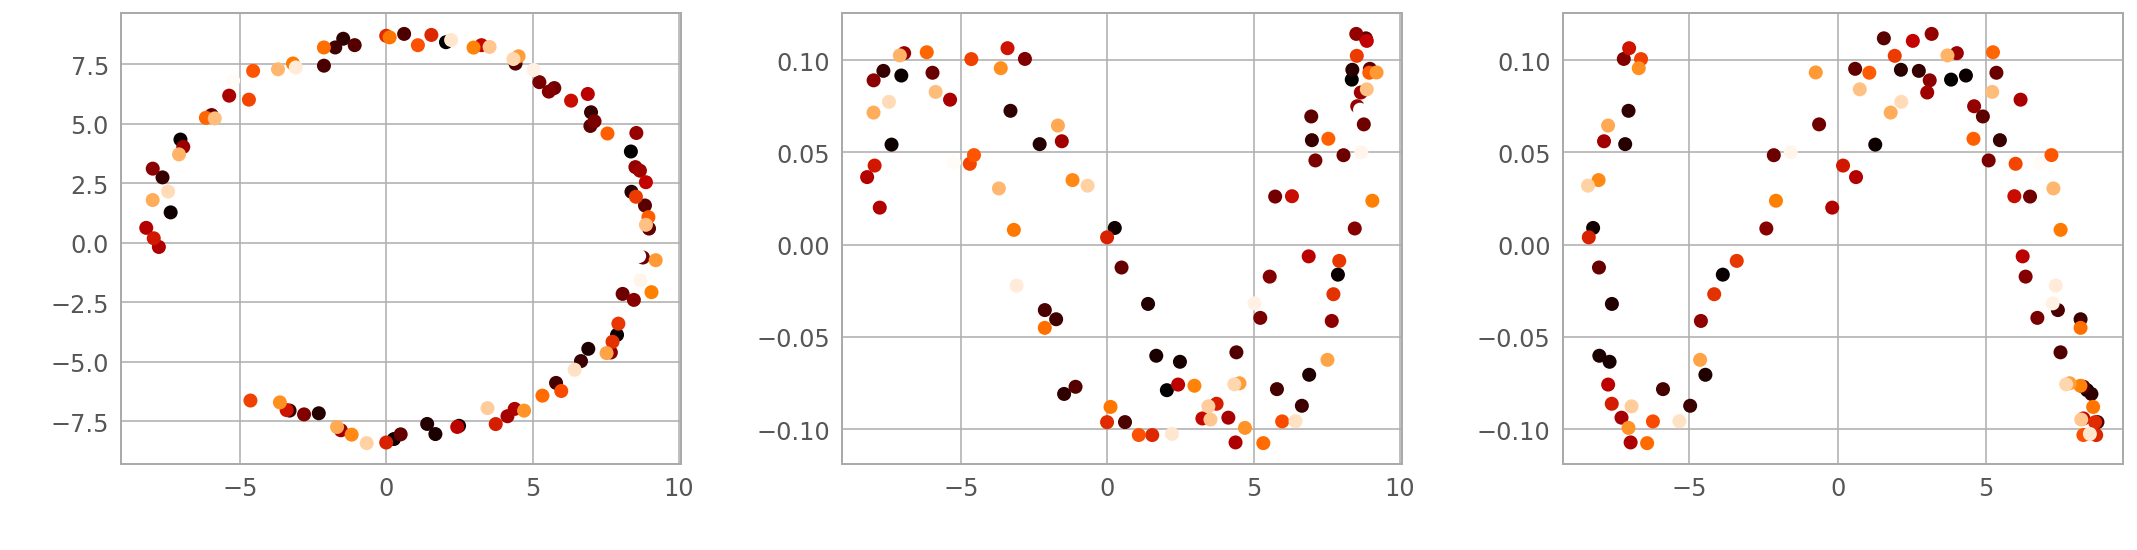

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(orb_obs.x, orb_obs.y, c=orb_clr)
axs[1].scatter(orb_obs.x, orb_obs.z, c=orb_clr)
axs[2].scatter(orb_obs.y, orb_obs.z, c=orb_clr)
plt.tight_layout()
plt.show();

### Preprocessing

100%|██████████| 10/10 [00:02<00:00,  4.62it/s]


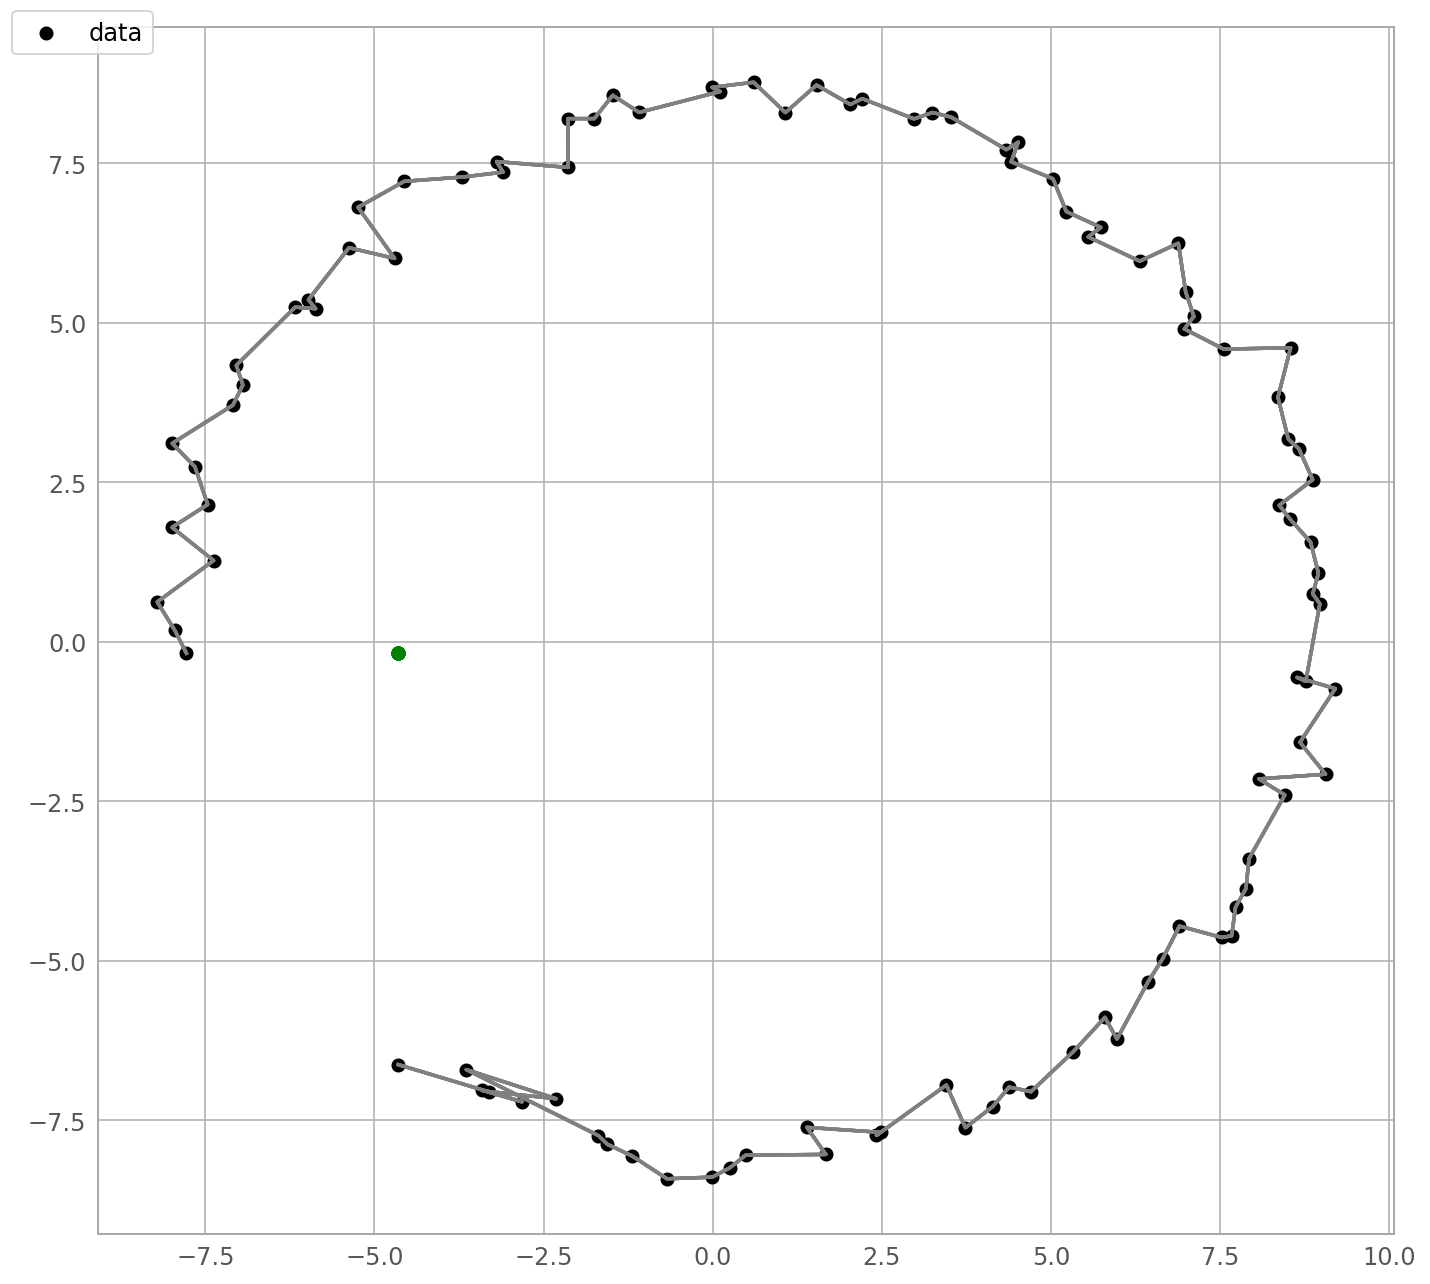

In [187]:
orb_repdata, orb_trmat, orb_visit_orders, orb_start_point = prep.preprocess(
    orb_obs,
    start_point=np.array((-6, -6, 0.0)),
    iterations=int(3e3),
    learning_rate=1.5,
    sigma=15,
    plot=True,
    N_repeats=np.arange(0, 10, 1),
    _tqdm=True,
)

orb_repdata *= u.kpc

orb_best_order = prep.draw_most_probable_ordering(orb_trmat)
orb_arr = orb_repdata[orb_best_order].xyz.T.value

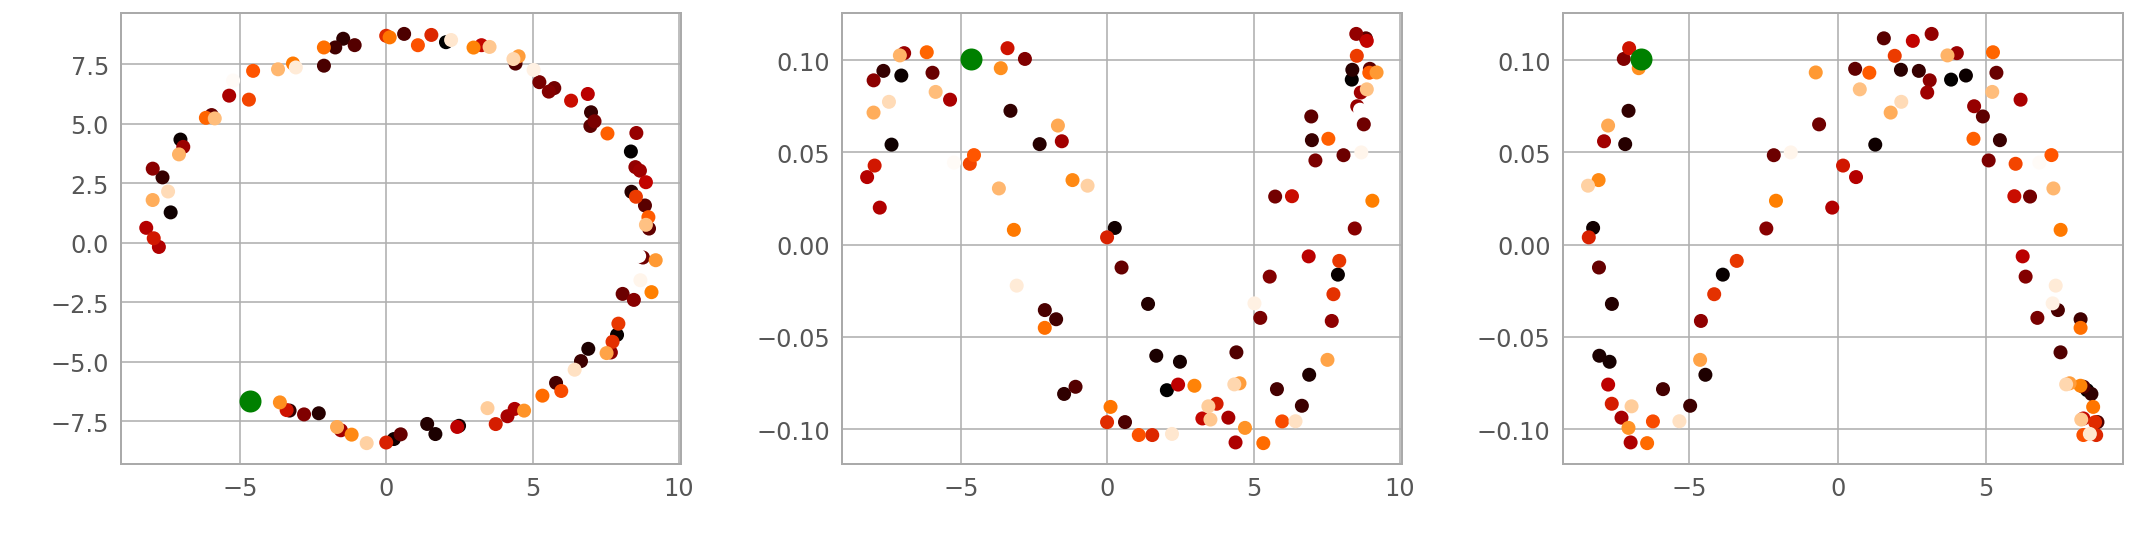

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(orb_obs.x, orb_obs.y, c=orb_clr)
axs[0].scatter(orb_start_point.x, orb_start_point.y, c="g", s=100)

axs[1].scatter(orb_obs.x, orb_obs.z, c=orb_clr)
axs[1].scatter(orb_start_point.x, orb_start_point.z, c="g", s=100)

axs[2].scatter(orb_obs.y, orb_obs.z, c=orb_clr)
axs[2].scatter(orb_start_point.y, orb_start_point.z, c="g", s=100)

plt.tight_layout()
plt.show();

### Kalman Filter

In [12]:
orb_kf = KalmanFilter(
    dim_x=6,  # x, dx, y, dy, z, dz
    dim_z=3,  # (x, y, z)
)

#### State transition function

For this function we implement a time dependency.

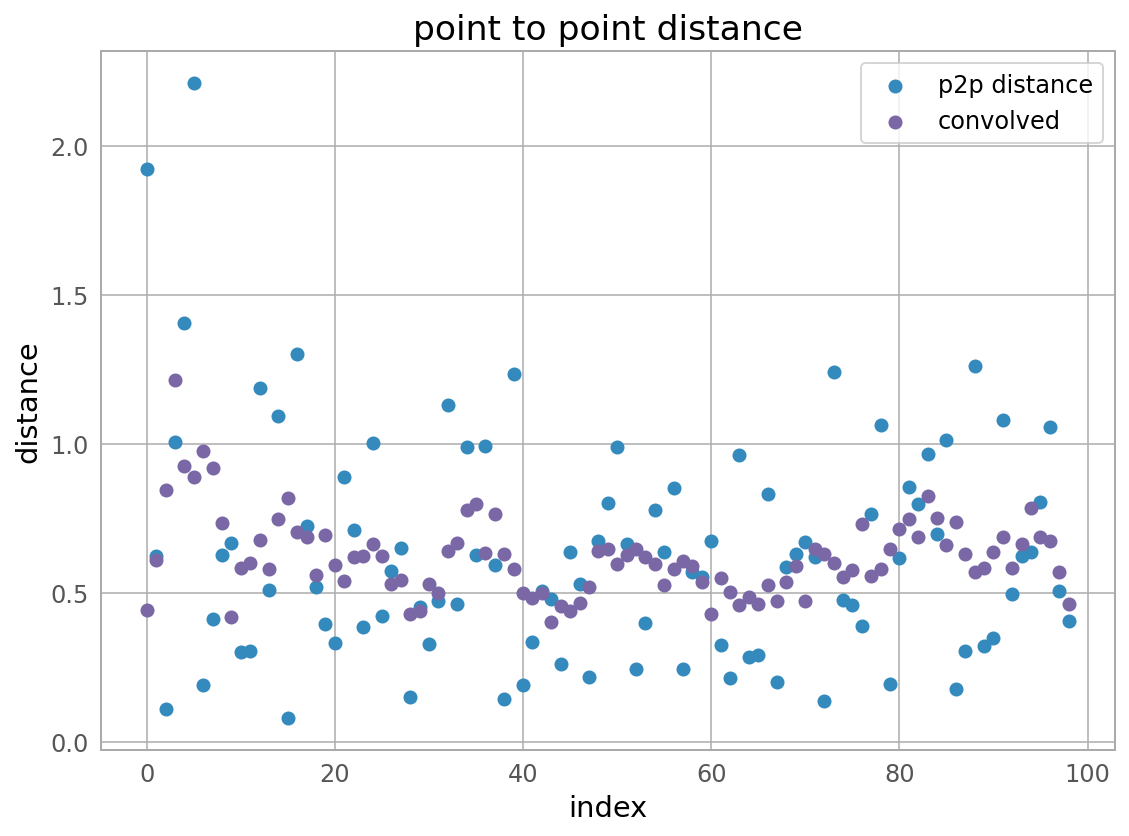

In [13]:
orb_dts = process.make_dts(orb_arr, dt0=0.5, N=6, axis=1, plot=True)
orb_dt = orb_dts[0]

In [14]:
orb_kf.F = process.make_F(orb_dt)
orb_kf.F

array([[1. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0.5],
       [0. , 0. , 0. , 0. , 0. , 1. ]])

#### Process noise matrix

In [15]:
orb_kf.Q = process.make_Q(dt=orb_dt, var=0.01, n_dims=3)

orb_kf.Q.shape
orb_kf.Q

(6, 6)

array([[0.00015625, 0.000625  , 0.        , 0.        , 0.        ,
        0.        ],
       [0.000625  , 0.0025    , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00015625, 0.000625  , 0.        ,
        0.        ],
       [0.        , 0.        , 0.000625  , 0.0025    , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.00015625,
        0.000625  ],
       [0.        , 0.        , 0.        , 0.        , 0.000625  ,
        0.0025    ]])

#### Measurement function

In [16]:
orb_kf.H = process.make_H()
orb_kf.H

array([[1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0]])

#### Measurement noise matrix

In [24]:
orb_kf.R = process.make_R([0.05, 0.05, 0.003])[0]  # error in x, y, z
orb_kf.R

array([[0.05 , 0.   , 0.   ],
       [0.   , 0.05 , 0.   ],
       [0.   , 0.   , 0.003]])

#### Initial conditions

Set the initial conditions to the first data point.

In [25]:
x = orb_arr[0]  # fist point
v = [0, 0, 0]

orb_kf.x = st.utils.intermix_arrays(x, v)  # intersperse velocity data
orb_kf.x

array([-4.6486003 ,  0.        , -6.62924275,  0.        ,  0.10061535,
        0.        ])

#### State Covariance

In [26]:
p = np.array([[0.0001, 0],  # very certain
              [0, 1]])  # very uncertain

P = block_diag(p, p, p)

orb_kf.P = P
orb_kf.P

array([[1.e-04, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00],
       [0.e+00, 1.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00],
       [0.e+00, 0.e+00, 1.e-04, 0.e+00, 0.e+00, 0.e+00],
       [0.e+00, 0.e+00, 0.e+00, 1.e+00, 0.e+00, 0.e+00],
       [0.e+00, 0.e+00, 0.e+00, 0.e+00, 1.e-04, 0.e+00],
       [0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 1.e+00]])

#### Run

In [35]:
orb_output, orb_smooth = run_with_updatestep(
    orb_arr, orb_dts, x0=orb_kf.x,
    P=orb_kf.P, R=orb_kf.R,
    H=orb_kf.H, u=0, B=0, alpha=1.,
    qkw=dict(dim=2, var=0.01, block_size=3)
#     qkw=dict(order=2, var=0.01, n_dims=3)
)

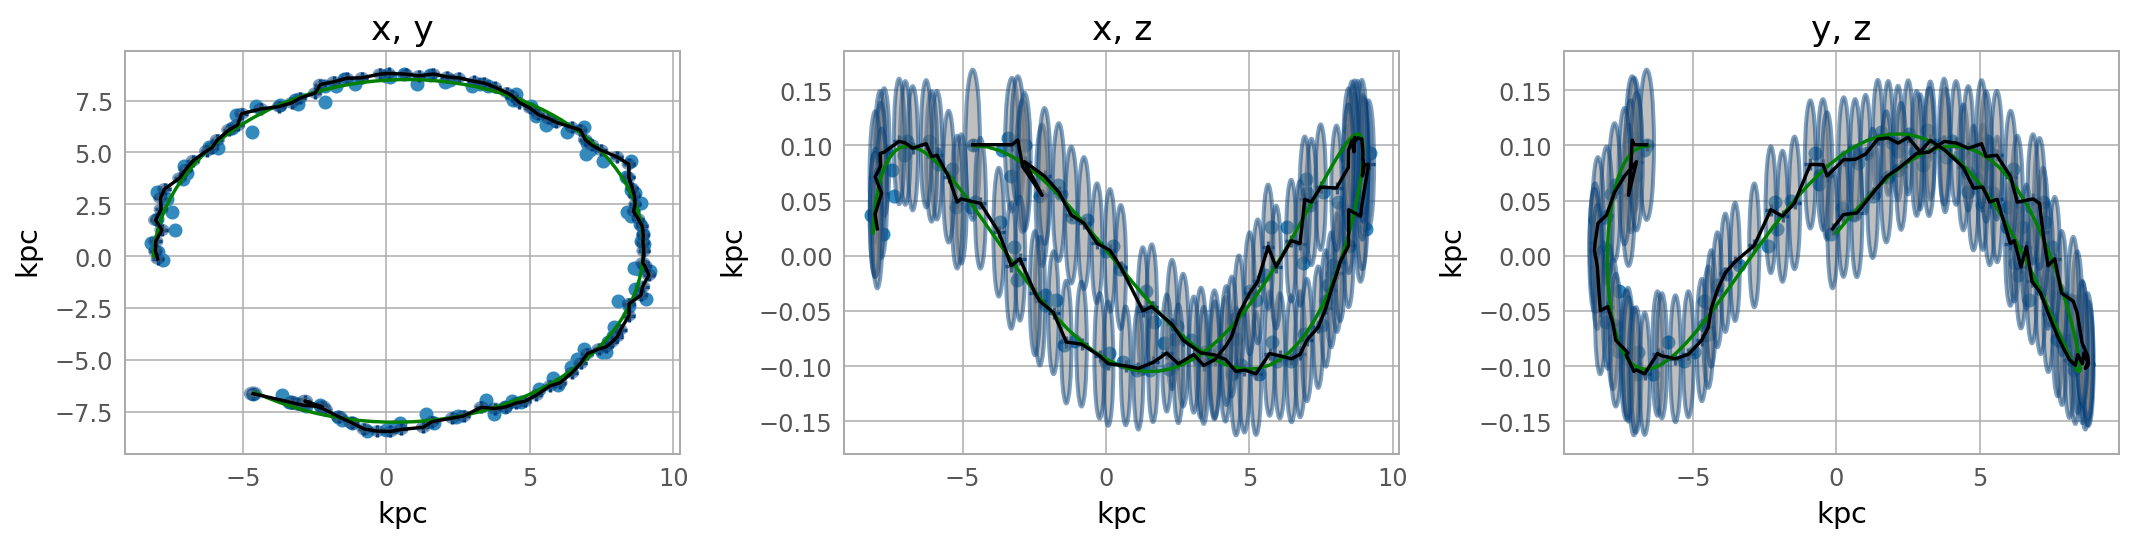

In [39]:
fig, axs = process.plot_path(
    orb_repdata,
    path=coord.CartesianRepresentation(x=orb_output.Xs[:,0]*u.kpc,
                                       y=orb_output.Xs[:,2]*u.kpc,
                                       z=orb_output.Xs[:,4]*u.kpc),
    cov=orb_output.Ps,
    true_path=orb_ord,
    num_std=1.25
);


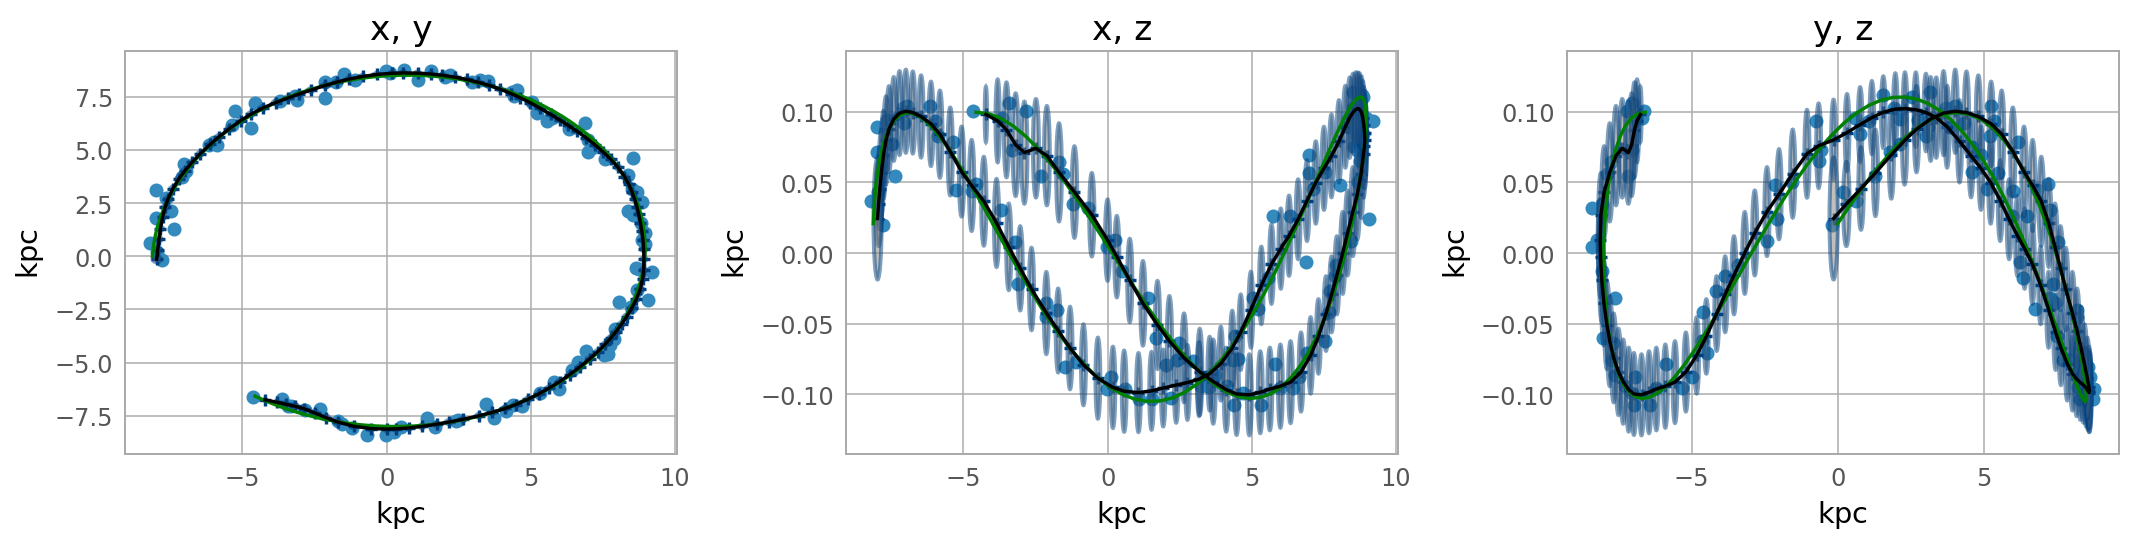

In [41]:
fig, axs = process.plot_path(
    orb_repdata,
    path = coord.CartesianRepresentation(x=orb_smooth.Xs[:,0]*u.kpc,
                                         y=orb_smooth.Xs[:,2]*u.kpc,
                                         z=orb_smooth.Xs[:,4]*u.kpc),
    cov=orb_smooth.Ps,
    true_path=orb_ord);


<br><br>

- - - 


## Nbody Data

In [42]:
nbd_obs = examples.get_nbody()

nbd_clr = np.linspace(0, 256, len(nbd_obs))

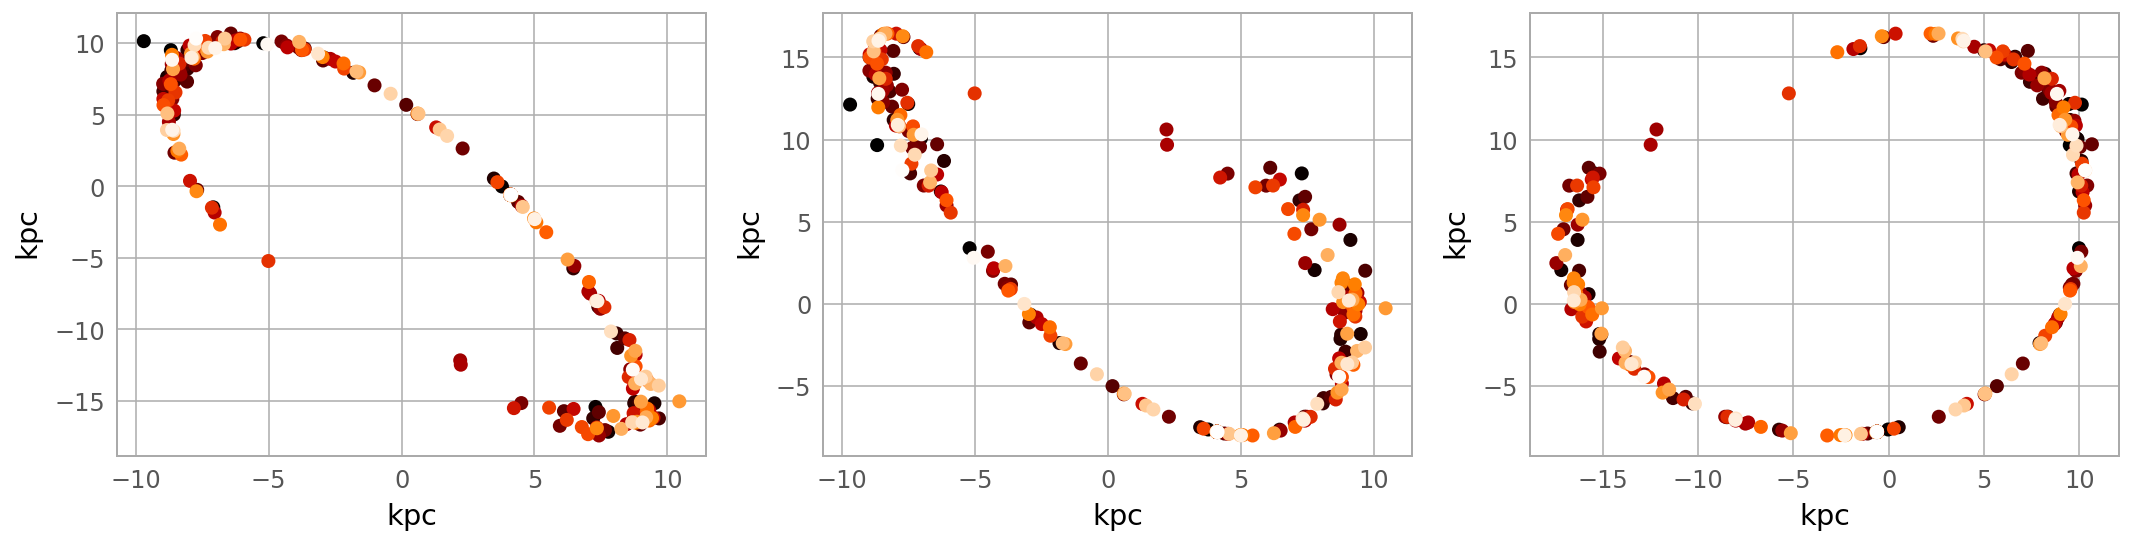

In [43]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(nbd_obs.x, nbd_obs.y, c=nbd_clr)
axs[1].scatter(nbd_obs.x, nbd_obs.z, c=nbd_clr)
axs[2].scatter(nbd_obs.y, nbd_obs.z, c=nbd_clr)
plt.tight_layout()
plt.show();

### Preprocessing

In [73]:
nbd_repdata, nbd_trmat, nbd_visit_orders, nbd_start_point = prep.preprocess(
    nbd_obs,
    start_point=np.array((-5, -5, 12.0))*u.kpc,
    iterations=int(3e3),
    learning_rate=2.,
    sigma=20,
    plot=False,
    N_repeats=np.arange(10, 20, 1),
    _tqdm=True,
)

nbd_best_order = prep.draw_most_probable_ordering(nbd_trmat)
nbd_arr = nbd_repdata[nbd_best_order].data.xyz.T.value

100%|██████████| 10/10 [00:03<00:00,  3.33it/s]


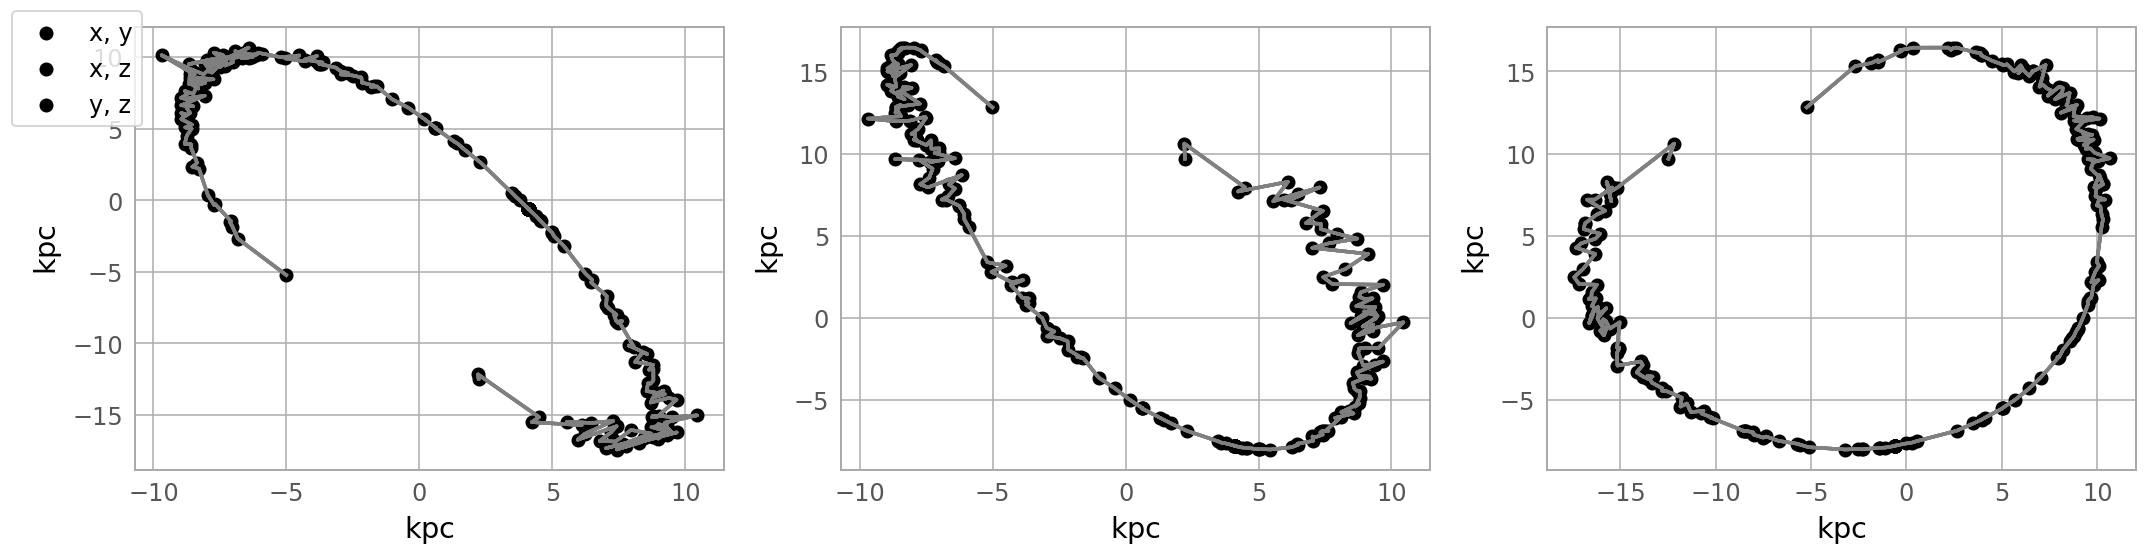

In [74]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# x, y
axs[0].scatter(nbd_repdata.x, nbd_repdata.y, label="x, y",
               c="k", vmax=len(nbd_repdata), cmap="plasma")
for order in nbd_visit_orders:
    axs[0].plot(nbd_repdata[order].x, nbd_repdata[order].y, c="gray", alpha=0.5)

# x, z
axs[1].scatter(nbd_repdata.x, nbd_repdata.z, label="x, z",
               c="k", vmax=len(nbd_repdata), cmap="plasma")
for order in nbd_visit_orders:
    axs[1].plot(nbd_repdata[order].x, nbd_repdata[order].z, c="gray", alpha=0.5)
    
# y, z
axs[2].scatter(nbd_repdata.y, nbd_repdata.z, label="y, z",
               c="k", vmax=len(nbd_repdata), cmap="plasma")
for order in nbd_visit_orders:
    axs[2].plot(nbd_repdata[order].y, nbd_repdata[order].z, c="gray", alpha=0.5)

fig.legend(loc="upper left")
fig.tight_layout()
plt.show();

### Kalman Filter

In [75]:
nbd_kf = KalmanFilter(
    dim_x=6,  # x, dx, y, dy, z, dz
    dim_z=3,  # (x, y, z)
)

#### State transition function

For this function we implement a time dependency.

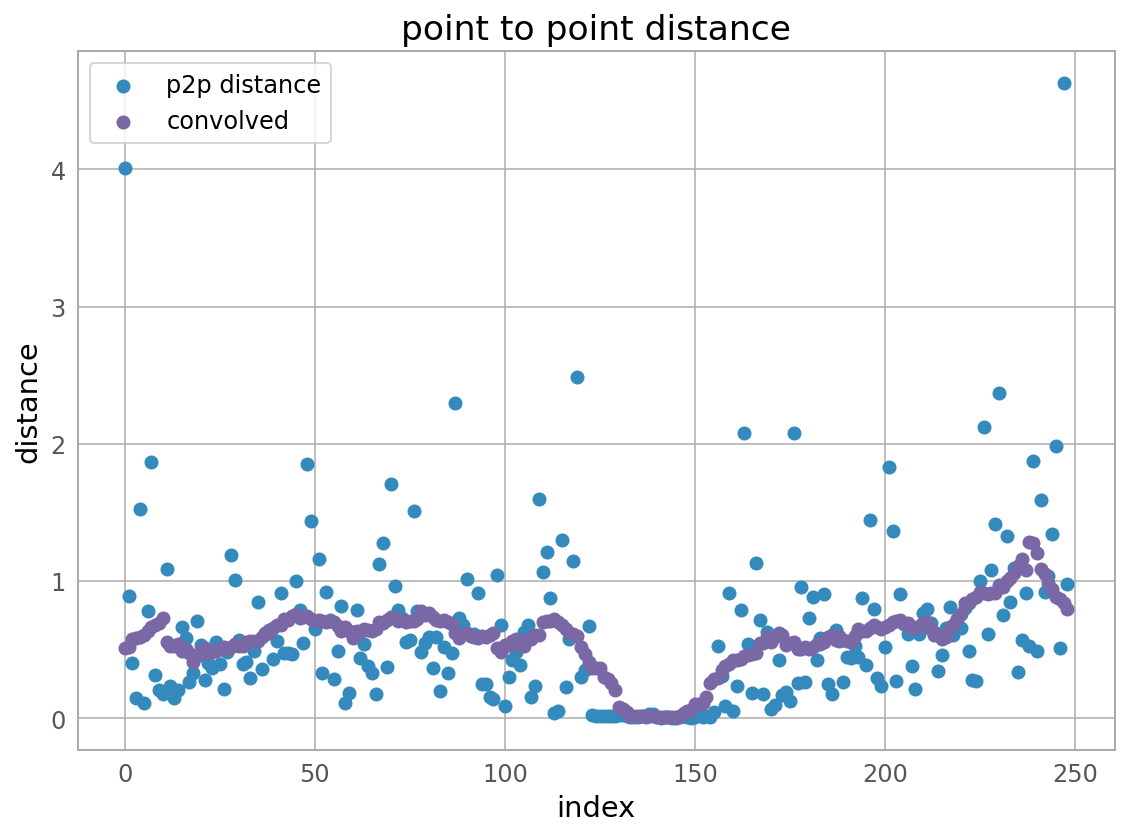

In [76]:
nbd_dts = make_dts(nbd_arr, dt0=0.5, vmin=0.01, N=20, axis=1, plot=True)
nbd_dt = nbd_dts[0]

In [77]:
orb_kf.F = make_F(nbd_dt)
orb_kf.F

array([[1. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0.5],
       [0. , 0. , 0. , 0. , 0. , 1. ]])

#### Process noise matrix

In [78]:
orb_kf.Q = make_Q(dim=2, dt=nbd_dt, var=0.01, block_size=3)
orb_kf.Q

array([[0.00015625, 0.000625  , 0.        , 0.        , 0.        ,
        0.        ],
       [0.000625  , 0.0025    , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00015625, 0.000625  , 0.        ,
        0.        ],
       [0.        , 0.        , 0.000625  , 0.0025    , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.00015625,
        0.000625  ],
       [0.        , 0.        , 0.        , 0.        , 0.000625  ,
        0.0025    ]])

#### Measurement function

In [79]:
# measurement components
# only measure the position 
h = np.array([[1, 0],
              [0, 0]])

# full matrix is for all components
# and reduce down to `dim_z` of Kalman Filter, skipping velocity rows
nbd_kf.H = block_diag(h, h, h)[::2]

nbd_kf.H

array([[1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0]])

#### Measurement noise matrix

In [80]:
nbd_kf.R = np.diag([
    0.05,  # error in x
    0.05,  # error in y
    0.003  # error in z
])

#### Initial conditions

Set the initial conditions to the first data point.

In [81]:
x = nbd_arr[0]  # fist point
v = [0, 0, 0]

nbd_kf.x = np.array([x, v]).T.flatten()  # intersperse velocity data
nbd_kf.x

array([-5.0065478 ,  0.        , -5.23145347,  0.        , 12.81172138,
        0.        ])

#### State Covariance

In [82]:
nbd_kf.P = np.eye(6) * 100.

#### Run

In [83]:
nbd_output, nbd_smooth = run_with_updatestep(nbd_arr, nbd_dts, x0=nbd_kf.x,
                                             P=nbd_kf.P, R=nbd_kf.R,
                                             H=nbd_kf.H, u=0, B=0, alpha=1.0,
                                             qkw=dict(dim=2, var=0.001, block_size=3))

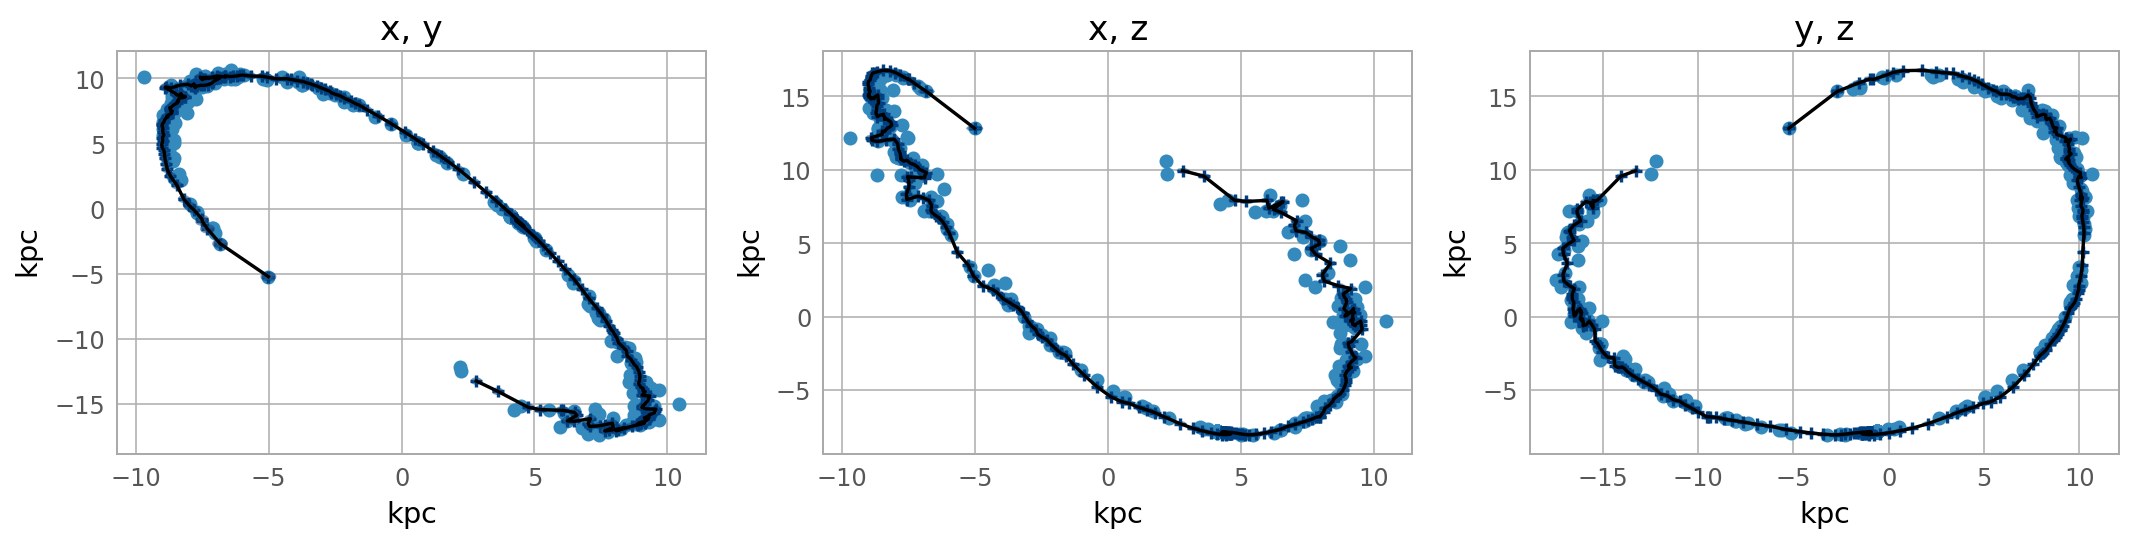

In [85]:
fig, axs = process.plot_path(
    nbd_repdata,
    path=coord.CartesianRepresentation(x=nbd_output.Xs[:,0]*u.kpc,
                                       y=nbd_output.Xs[:,2]*u.kpc,
                                       z=nbd_output.Xs[:,4]*u.kpc),
    cov=nbd_output.Ps);


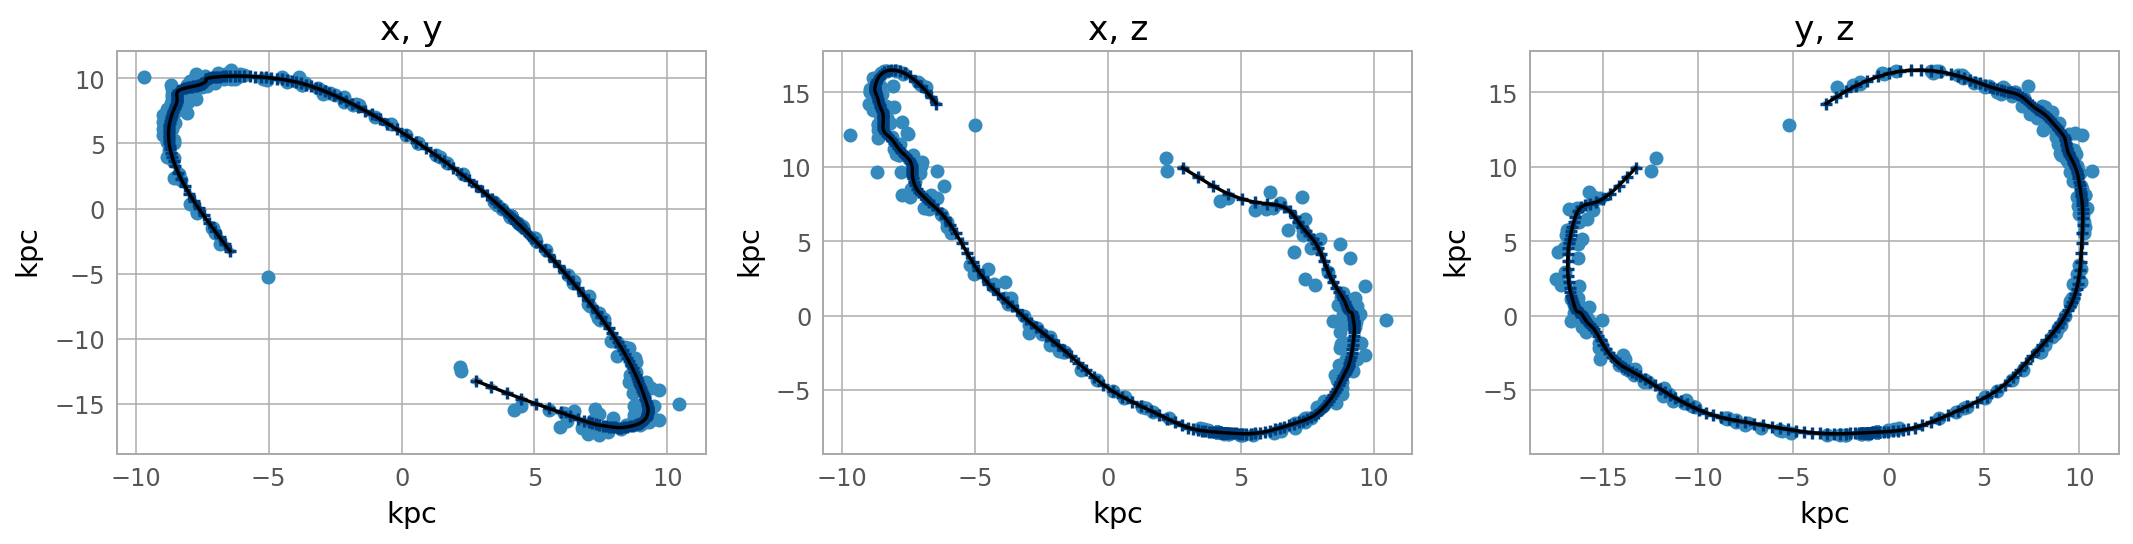

In [86]:
process.plot_path(nbd_repdata.data,
          path=coord.CartesianRepresentation(x=nbd_smooth.Xs[:,0] * u.kpc,
                                             y=nbd_smooth.Xs[:,2] * u.kpc,
                                             z=nbd_smooth.Xs[:,4] * u.kpc),
          cov=nbd_smooth.Ps
);

<br><br>

- - - 


## Obs Data

In [173]:
pal5_obs = examples.get_stream_data().cartesian
# pal5_obs = pal5_obs[pal5_obs.x > -0.645]

pal5_clr = np.linspace(0, 256, len(pal5_obs))

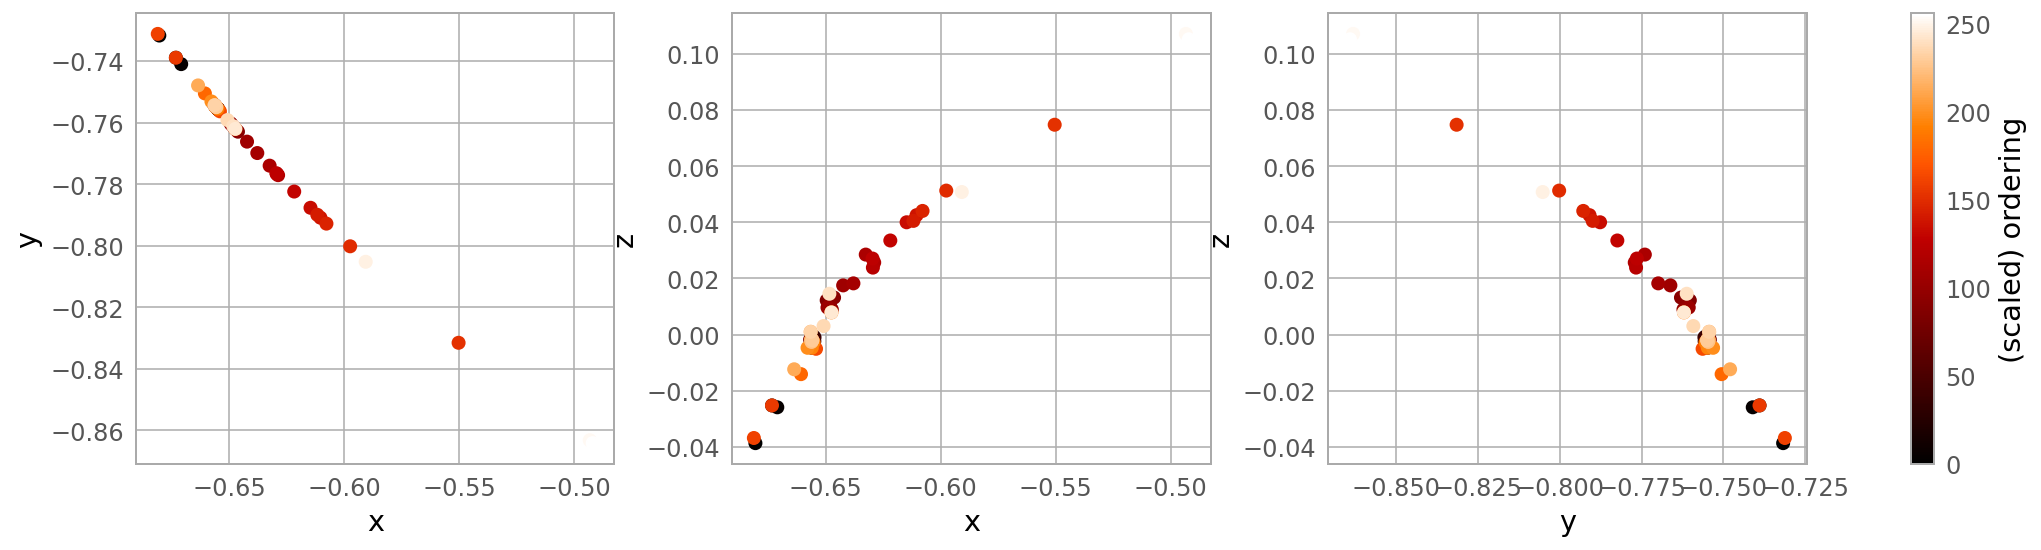

In [174]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

axs[0].scatter(pal5_obs.x, pal5_obs.y, c=pal5_clr)
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

axs[1].scatter(pal5_obs.x, pal5_obs.z, c=pal5_clr)
axs[1].set_xlabel("x")
axs[1].set_ylabel("z")

scat = axs[2].scatter(pal5_obs.y, pal5_obs.z, c=pal5_clr)
axs[2].set_xlabel("y")
axs[2].set_ylabel("z")

plt.tight_layout()
cbar = plt.colorbar(scat, ax=axs)
cbar.ax.set_ylabel("(scaled) ordering")
plt.show();

### Preprocessing

In [175]:
pal5_repdata, pal5_trmat, pal5_visit_orders, pal5_start_point = prep.preprocess(
    pal5_obs,
    start_point=np.array((-0.7, -0.72, -0.04)),
    iterations=int(3e3),
    learning_rate=2.,
    sigma=20,
    plot=False,
    N_repeats=np.arange(10, 20, 1),
    _tqdm=True,
)

pal5_best_order = prep.draw_most_probable_ordering(pal5_trmat)
pal5_arr = pal5_repdata[pal5_best_order].xyz.T.value

100%|██████████| 10/10 [00:01<00:00,  6.20it/s]


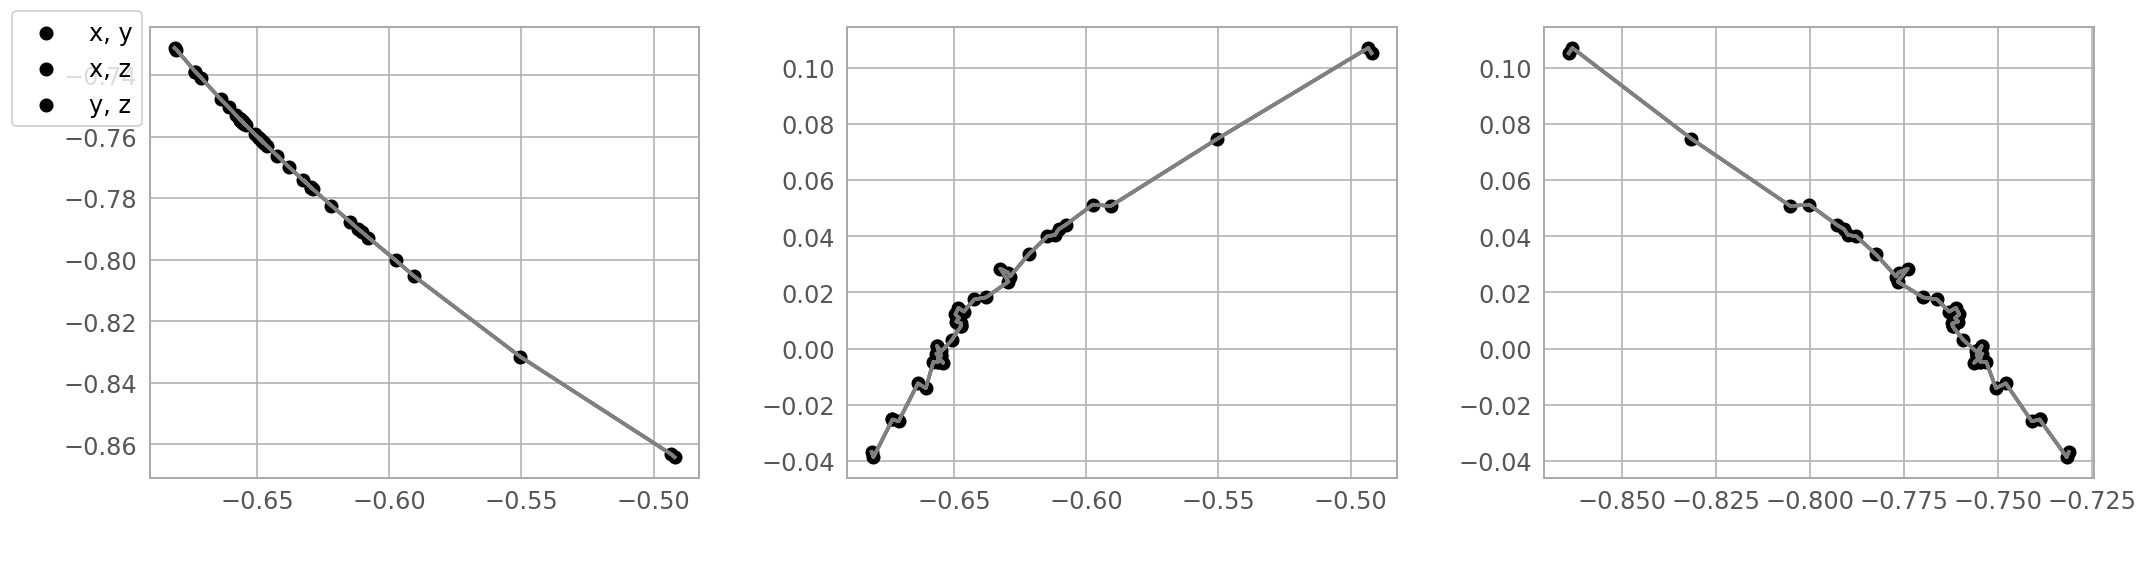

In [176]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# x, y
axs[0].scatter(pal5_repdata.x, pal5_repdata.y, label="x, y",
               c="k", vmax=len(pal5_repdata), cmap="plasma")
for order in pal5_visit_orders:
    axs[0].plot(pal5_repdata[order].x, pal5_repdata[order].y, c="gray", alpha=0.5)

# x, z
axs[1].scatter(pal5_repdata.x, pal5_repdata.z, label="x, z",
               c="k", vmax=len(pal5_repdata), cmap="plasma")
for order in pal5_visit_orders:
    axs[1].plot(pal5_repdata[order].x, pal5_repdata[order].z, c="gray", alpha=0.5)
    
# y, z
axs[2].scatter(pal5_repdata.y, pal5_repdata.z, label="y, z",
               c="k", vmax=len(pal5_repdata), cmap="plasma")
for order in pal5_visit_orders:
    axs[2].plot(pal5_repdata[order].y, pal5_repdata[order].z, c="gray", alpha=0.5)

fig.legend(loc="upper left")
fig.tight_layout()
plt.show();

### Kalman Filter

In [177]:
pal5_kf = KalmanFilter(
    dim_x=6,  # x, dx, y, dy, z, dz
    dim_z=3,  # x, y, z
)

#### State transition function

For this function we implement a time dependency.

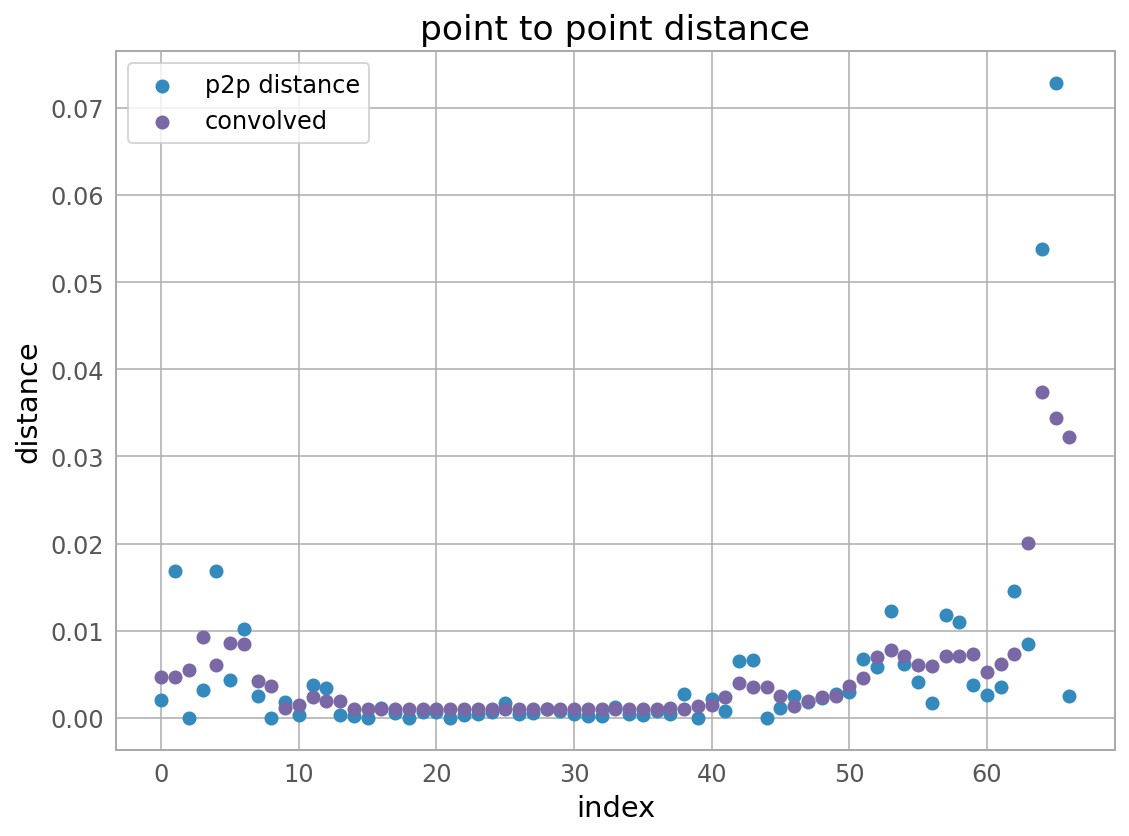

In [178]:
pal5_dts = make_dts(pal5_arr, dt0=0.5, vmin=0.001, N=4, axis=1, plot=True)
pal5_dt = pal5_dts[0]

In [179]:
pal5_kf.F = make_F(pal5_dt)

pal5_kf.F


array([[1. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0.5],
       [0. , 0. , 0. , 0. , 0. , 1. ]])

#### Process noise matrix

In [180]:
pal5_kf.Q = make_Q(dim=2, dt=pal5_dt, var=0.01, block_size=3)

pal5_kf.Q

array([[0.00015625, 0.000625  , 0.        , 0.        , 0.        ,
        0.        ],
       [0.000625  , 0.0025    , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00015625, 0.000625  , 0.        ,
        0.        ],
       [0.        , 0.        , 0.000625  , 0.0025    , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.00015625,
        0.000625  ],
       [0.        , 0.        , 0.        , 0.        , 0.000625  ,
        0.0025    ]])

#### Measurement function

In [181]:
# measurement components
# only measure the position 
h = np.array([[1, 0],
              [0, 0]])

# full matrix is for all components
# and reduce down to `dim_z` of Kalman Filter, skipping velocity rows
pal5_kf.H = block_diag(h, h, h)[::2]

pal5_kf.H

array([[1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0]])

#### Measurement noise matrix

In [182]:
pal5_kf.R = np.diag([
    1e-4,  # error in x
    1e-4,  # error in y
    1e-4  # error in z
])

#### Initial conditions

Set the initial conditions to the first data point.

In [183]:
x = pal5_arr[0]  # fist point
v = [1, 1, 1]

pal5_kf.x = np.array([x, v]).T.flatten()  # intersperse velocity data
pal5_kf.x

array([-0.68115543,  1.        , -0.73121188,  1.        , -0.03683024,
        1.        ])

#### State Covariance

In [184]:
p = np.array([[0.001, 0],  # very certain
              [0, 100]])  # very uncertain

P = block_diag(p, p, p)

pal5_kf.P = P
pal5_kf.P

array([[1.e-03, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00],
       [0.e+00, 1.e+02, 0.e+00, 0.e+00, 0.e+00, 0.e+00],
       [0.e+00, 0.e+00, 1.e-03, 0.e+00, 0.e+00, 0.e+00],
       [0.e+00, 0.e+00, 0.e+00, 1.e+02, 0.e+00, 0.e+00],
       [0.e+00, 0.e+00, 0.e+00, 0.e+00, 1.e-03, 0.e+00],
       [0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 1.e+02]])

#### Run

In [185]:
pal5_output, pal5_smooth = run_with_updatestep(pal5_arr[::-1], pal5_dts, x0=pal5_kf.x,
                                               P=pal5_kf.P, R=pal5_kf.R,
                                               H=pal5_kf.H, u=0, B=0, alpha=1.,
                                               qkw=dict(dim=2, var=0.01, block_size=3))

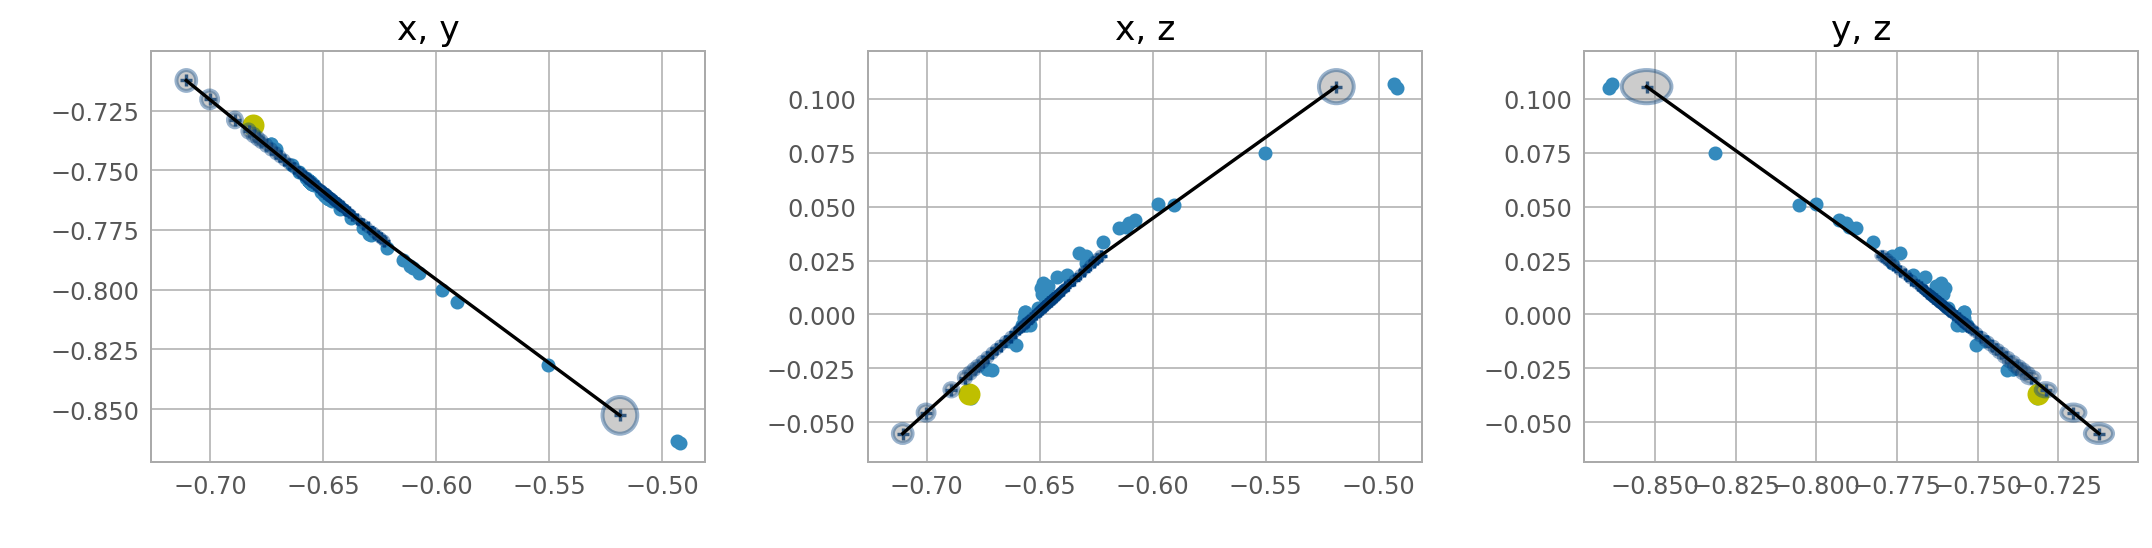

In [186]:
process.plot_path(
    pal5_repdata,
    path=coord.CartesianRepresentation(x=pal5_smooth.Xs[:,0],
                                       y=pal5_smooth.Xs[:,2],
                                       z=pal5_smooth.Xs[:,4]),
          cov=pal5_smooth.Ps,
          is_ordered=True,
          cov_alpha=0.4
);

<br><br>

- - - 

<span style='font-size:40px;font-weight:650'>
    END
</span>